# Warehouse Order Processing Time Prediction

## 1. Business Problem

### Objective
Predict the time required to process a warehouse order based on
order characteristics and warehouse operational factors.

### Target Variable
"processing_time_minutes"

### Machine Learning Problem
Regression

### Primary Algorithm
Linear Regression

In [1]:
## Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# supress the warnings
import warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv("../data/raw/warehouse_orders_raw.csv")

In [3]:
df.head()

,order_id,order_date,shift,warehouse_zone,priority,equipment_type,day_of_week,number_of_items,total_quantity,number_of_skus,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,temperature_c,processing_time_minutes
0,104680,2026-07-14 23:00:00,Afternoon,B,Standard,Trolley,Tuesday,10,22,8,5.98,388.0,31.0,1,0.414,0,27.4,38.18
1,110474,2027-03-13 09:00:00,Morning,C,Standard,Manual,Saturday,11,33,7,18.97,507.2,31.0,1,0.260,0,25.5,60.78
2,110501,2027-03-14 12:00:00,Morning,B,Standard,Trolley,Sunday,9,28,8,5.91,403.5,8.0,1,0.254,0,26.7,36.50
3,108702,2026-12-29 13:00:00,Night,B,Standard,Manual,Tuesday,9,19,7,13.46,489.2,53.0,3,0.336,0,25.7,39.86
4,107174,2026-10-26 21:00:00,Afternoon,B,Standard,Manual,Monday,11,33,9,13.01,655.1,20.0,2,0.511,3,34.6,44.72


In [8]:
df.shape

(12025, 18)

In [11]:
df.describe()

,order_id,number_of_items,total_quantity,number_of_skus,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,temperature_c,processing_time_minutes
count,12025.000000,12025.000000,12025.000000,12025.000000,11809.000000,11881.000000,11845.000000,12025.000000,11905.000000,12025.000000,12025.000000,12025.000000
mean,106001.148358,12.016216,32.743119,10.025281,17.273013,584.060340,25.596792,2.215218,0.435239,0.790936,26.979925,45.515079
std,3464.179319,3.317801,17.372579,3.587819,10.944670,182.886007,14.175595,1.054369,0.116749,0.891317,3.981953,13.683732
min,100001.000000,1.000000,3.000000,1.000000,0.400000,90.000000,1.000000,1.000000,0.166000,0.000000,12.500000,5.000000
25%,103001.000000,10.000000,19.000000,8.000000,9.120000,461.100000,15.000000,1.000000,0.346000,0.000000,24.300000,36.040000
50%,106000.000000,12.000000,30.000000,10.000000,14.860000,568.300000,23.000000,2.000000,0.428000,1.000000,27.000000,44.890000
75%,109001.000000,14.000000,43.000000,12.000000,22.960000,691.200000,33.000000,3.000000,0.517000,1.000000,29.700000,54.280000
max,112000.000000,26.000000,125.000000,25.000000,87.890000,3309.000000,102.000000,5.000000,0.820000,6.000000,41.900000,139.620000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12025 entries, 0 to 12024
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  12025 non-null  int64  
 1   order_date                12025 non-null  object 
 2   shift                     12025 non-null  object 
 3   warehouse_zone            12025 non-null  object 
 4   priority                  11929 non-null  object 
 5   equipment_type            11904 non-null  object 
 6   day_of_week               12025 non-null  object 
 7   number_of_items           12025 non-null  int64  
 8   total_quantity            12025 non-null  int64  
 9   number_of_skus            12025 non-null  int64  
 10  order_weight_kg           11809 non-null  float64
 11  picking_distance_m        11881 non-null  float64
 12  picker_experience_months  11845 non-null  float64
 13  number_of_pickers         12025 non-null  int64  
 14  wareho

In [22]:
# checking Datatypes
df.dtypes

order_id                      int64
order_date                   object
shift                        object
warehouse_zone               object
priority                     object
equipment_type               object
day_of_week                  object
number_of_items               int64
total_quantity                int64
number_of_skus                int64
order_weight_kg             float64
picking_distance_m          float64
picker_experience_months    float64
number_of_pickers             int64
warehouse_congestion        float64
fragile_items                 int64
temperature_c               float64
processing_time_minutes     float64
dtype: object

In [13]:
df.dtypes.value_counts()

int64      6
object     6
float64    6
Name: count, dtype: int64

In [16]:
df.select_dtypes(include="object").columns

Index(['order_date', 'shift', 'warehouse_zone', 'priority', 'equipment_type',
       'day_of_week'],
      dtype='object')

In [17]:
df.select_dtypes(include="number").columns

Index(['order_id', 'number_of_items', 'total_quantity', 'number_of_skus',
       'order_weight_kg', 'picking_distance_m', 'picker_experience_months',
       'number_of_pickers', 'warehouse_congestion', 'fragile_items',
       'temperature_c', 'processing_time_minutes'],
      dtype='object')

In [23]:
## Checking Null Values

df.isnull().sum()

order_id                      0
order_date                    0
shift                         0
warehouse_zone                0
priority                     96
equipment_type              121
day_of_week                   0
number_of_items               0
total_quantity                0
number_of_skus                0
order_weight_kg             216
picking_distance_m          144
picker_experience_months    180
number_of_pickers             0
warehouse_congestion        120
fragile_items                 0
temperature_c                 0
processing_time_minutes       0
dtype: int64

In [20]:
# % Of null values

(df.isnull().sum()/len(df)*100).sort_values(ascending= False)

order_weight_kg             1.796258
picker_experience_months    1.496881
picking_distance_m          1.197505
equipment_type              1.006237
warehouse_congestion        0.997921
priority                    0.798337
order_id                    0.000000
temperature_c               0.000000
fragile_items               0.000000
number_of_pickers           0.000000
number_of_skus              0.000000
order_date                  0.000000
total_quantity              0.000000
number_of_items             0.000000
day_of_week                 0.000000
warehouse_zone              0.000000
shift                       0.000000
processing_time_minutes     0.000000
dtype: float64

In [24]:
# Duplicate Value Analysis

df.duplicated().sum()

25

In [26]:
df[df.duplicated()]

,order_id,order_date,shift,warehouse_zone,priority,equipment_type,day_of_week,number_of_items,total_quantity,number_of_skus,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,temperature_c,processing_time_minutes
4178,101393,2026-02-28 00:00:00,Morning,A,Standard,Trolley,Saturday,14,43,12,12.17,734.5,8.0,2,0.350,0,31.2,43.62
4184,111758,2027-05-05 21:00:00,Night,A,High,Manual,Wednesday,11,12,11,6.74,498.9,10.0,2,0.598,2,26.8,62.28
4574,106984,2026-10-18 23:00:00,Night,B,Standard,NaN,Sunday,9,36,7,8.95,470.5,31.0,1,0.466,1,36.5,52.35
5139,104573,2026-07-10 12:00:00,Morning,E,Standard,Trolley,Friday,11,33,10,11.89,498.8,22.0,2,0.284,0,27.5,41.96
5449,102519,2026-04-15 22:00:00,Afternoon,E,High,Forklift,Wednesday,10,10,9,3.16,576.9,33.0,1,0.206,0,30.1,33.29
6418,101424,2026-03-01 07:00:00,Morning,D,Standard,Conveyor,Sunday,11,33,10,27.82,584.7,12.0,2,0.486,0,26.9,41.18
6864,107415,2026-11-05 22:00:00,Afternoon,C,High,Trolley,Thursday,9,27,8,13.01,499.8,9.0,1,0.413,2,28.7,43.39
8035,103090,2026-05-09 17:00:00,Morning,B,Urgent,Manual,Saturday,11,34,7,9.55,409.3,17.0,2,0.620,0,22.1,48.06
8415,102916,2026-05-02 11:00:00,Afternoon,A,High,Conveyor,Saturday,7,36,5,NaN,253.3,37.0,2,0.497,0,24.8,19.76
8883,103631,2026-06-01 06:00:00,Afternoon,B,Standard,Trolley,Monday,18,19,14,7.65,575.8,49.0,2,0.365,0,23.2,53.60


In [49]:
## Categorical variable analysis

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['order_date',
 'shift',
 'warehouse_zone',
 'priority',
 'equipment_type',
 'day_of_week']

In [44]:
df[categorical_cols].nunique()

order_date        12000
shift                 3
warehouse_zone        5
priority              3
equipment_type        4
day_of_week           7
dtype: int64

In [50]:
# remove date to avoid print 12k unique values

categorical_cols.remove('order_date')

In [47]:
categorical_cols

['shift', 'warehouse_zone', 'priority', 'equipment_type', 'day_of_week']

In [52]:
## check unique values in each column

for i in categorical_cols:
    print(i)
    print(df[i].unique())
    print("-------------------")
    

shift
['Afternoon' 'Morning' 'Night']
-------------------
warehouse_zone
['B' 'C' 'E' 'A' 'D']
-------------------
priority
['Standard' 'High' 'Urgent' nan]
-------------------
equipment_type
['Trolley' 'Manual' 'Conveyor' 'Forklift' nan]
-------------------
day_of_week
['Tuesday' 'Saturday' 'Sunday' 'Monday' 'Thursday' 'Friday' 'Wednesday']
-------------------


In [56]:
for i in categorical_cols:
    print(f'\n------------------')
    print(df[i].value_counts())
    


------------------
shift
Morning      5126
Afternoon    4764
Night        2135
Name: count, dtype: int64

------------------
warehouse_zone
A    2922
B    2622
C    2401
D    2216
E    1864
Name: count, dtype: int64

------------------
priority
Standard    8481
High        2766
Urgent       682
Name: count, dtype: int64

------------------
equipment_type
Trolley     5764
Conveyor    2921
Manual      1819
Forklift    1400
Name: count, dtype: int64

------------------
day_of_week
Saturday     1734
Friday       1732
Thursday     1730
Wednesday    1709
Tuesday      1707
Sunday       1707
Monday       1706
Name: count, dtype: int64


In [69]:
# Analyzing Nummerical columns

numerical_cols = df.select_dtypes(include='number').columns.drop('order_id')
numerical_cols

Index(['number_of_items', 'total_quantity', 'number_of_skus',
       'order_weight_kg', 'picking_distance_m', 'picker_experience_months',
       'number_of_pickers', 'warehouse_congestion', 'fragile_items',
       'temperature_c', 'processing_time_minutes'],
      dtype='object')

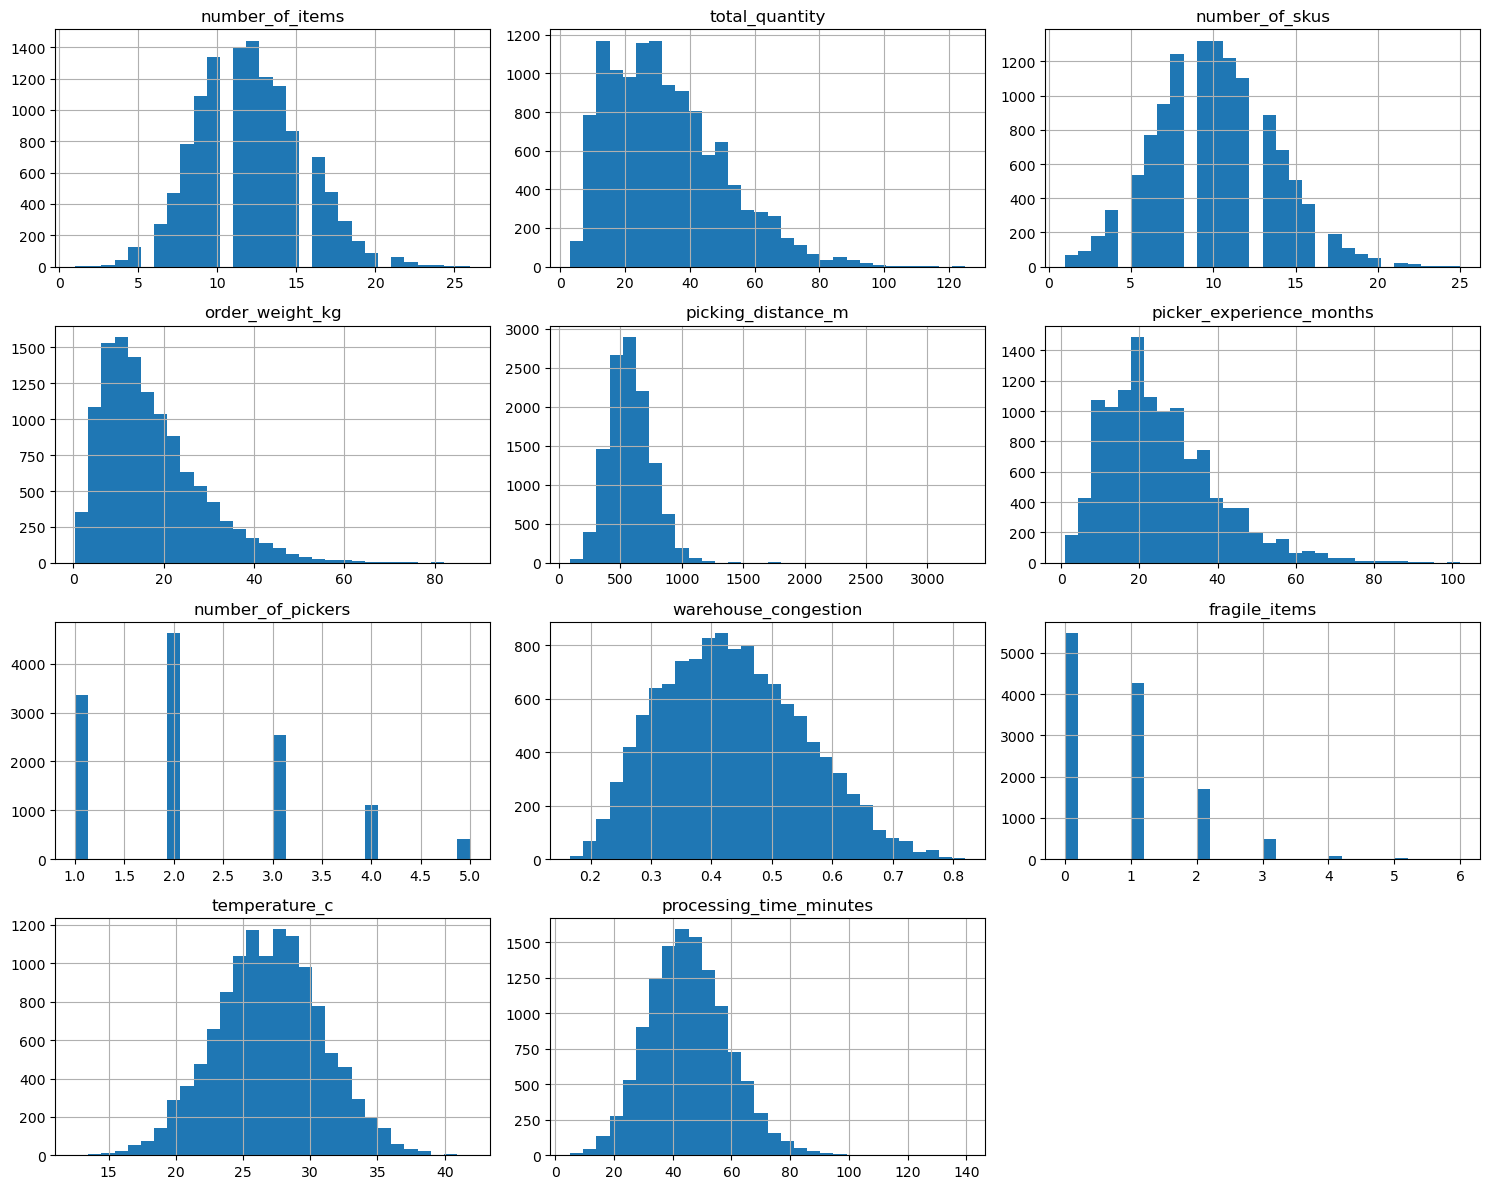

In [75]:
## Checking Distribution of numerical columns

df[numerical_cols].hist(figsize=(15, 12),bins=30)

plt.tight_layout()
plt.show()

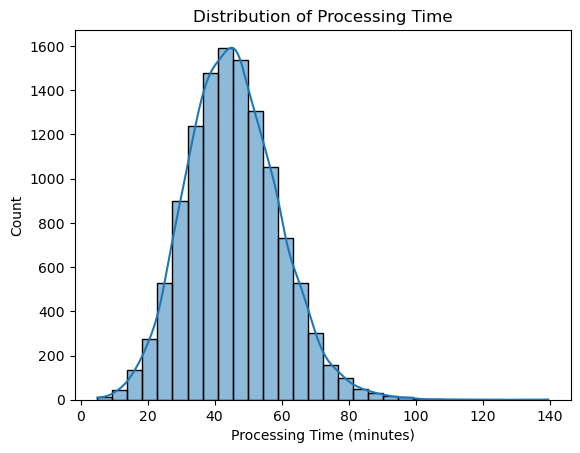

In [78]:
sns.histplot(df['processing_time_minutes'], bins= 30, kde= True)

plt.title('Distribution of Processing Time')
plt.xlabel('Processing Time (minutes)')
plt.show()


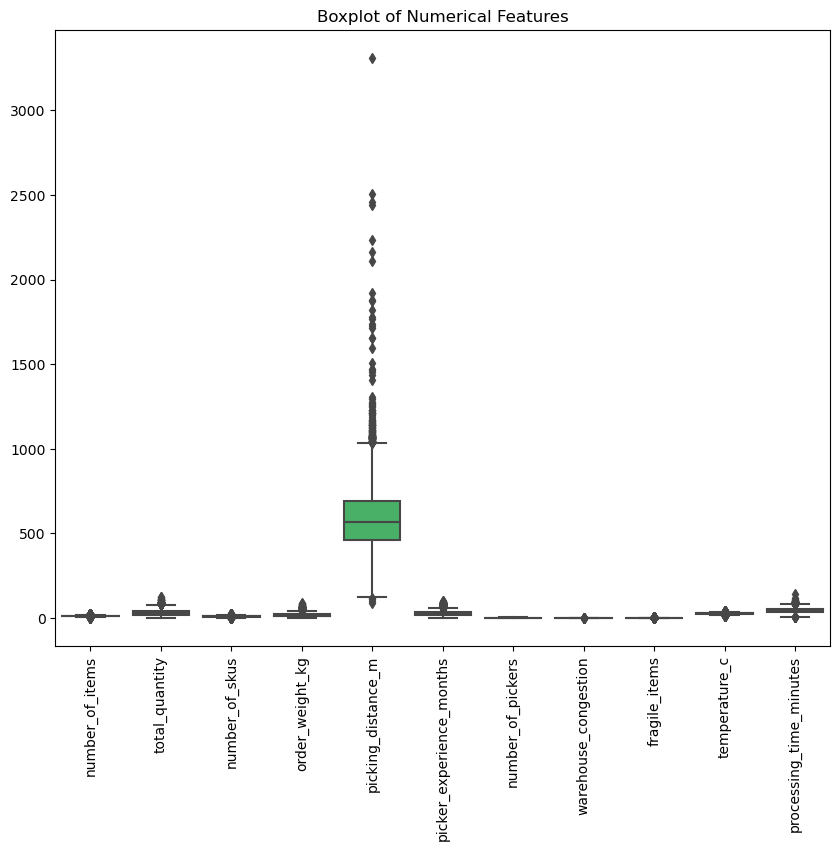

In [88]:
#combined boxplot to see teh outliers

plt.figure(figsize=(10, 8))

sns.boxplot(data=df[numerical_cols])

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

##### Few features seems to have outliers. we will plot them individually

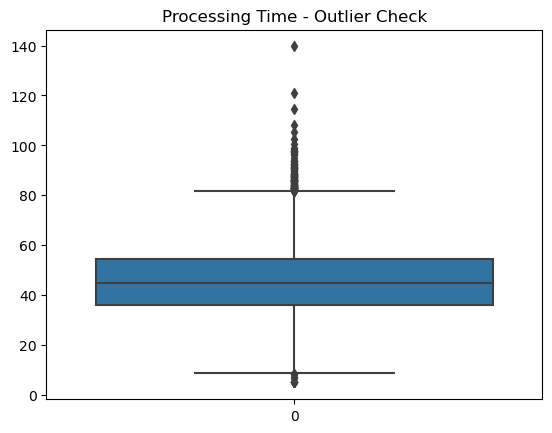

In [96]:
sns.boxplot(data = df["processing_time_minutes"])
plt.title("Processing Time - Outlier Check")
plt.show()

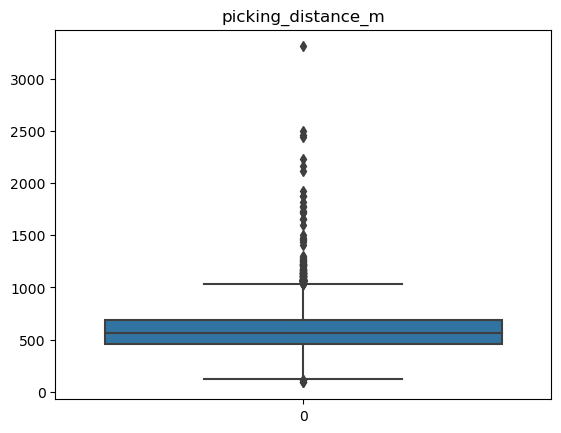

In [100]:
sns.boxplot(data = df['picking_distance_m'])
plt.title("picking_distance_m")
plt.show()

In [ ]:
picker_experience_months

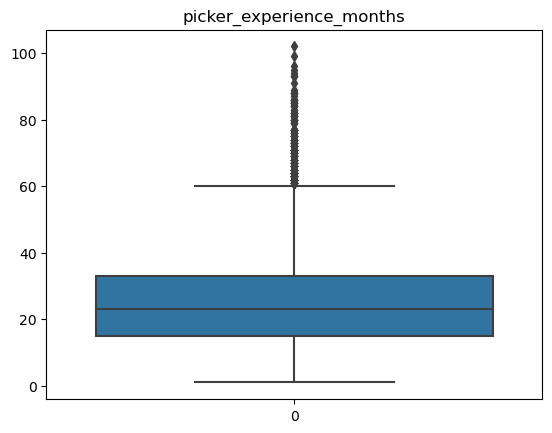

In [102]:
sns.boxplot(data = df["picker_experience_months"])
plt.title("picker_experience_months")
plt.show()

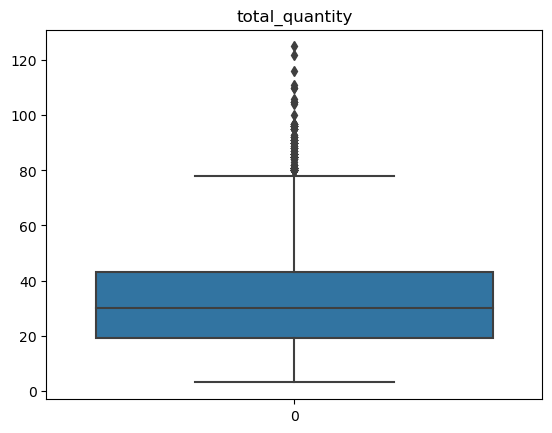

In [103]:
sns.boxplot(data = df["total_quantity"])
plt.title("total_quantity")
plt.show()

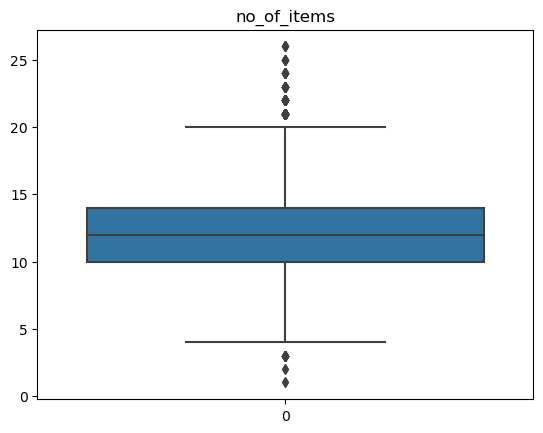

In [105]:
sns.boxplot(data = df["number_of_items"])
plt.title("no_of_items")
plt.show()

### Several numerical variables contain observations outside the IQR boundaries. These observations will be investigated further during preprocessing to distinguish genuine operational variability from potential data-quality issues.

### Correlation analysis

In [107]:
# correlation with target

target_corr = df[numerical_cols].corr()['processing_time_minutes'].sort_values(ascending=False)
    
target_corr

processing_time_minutes     1.000000
number_of_items             0.711991
total_quantity              0.674578
number_of_skus              0.662433
picking_distance_m          0.661821
order_weight_kg             0.583118
warehouse_congestion        0.043924
fragile_items               0.039177
temperature_c              -0.013230
picker_experience_months   -0.064744
number_of_pickers          -0.107998
Name: processing_time_minutes, dtype: float64

In [115]:
#Overall Correlation within numeric data

target_corr1 = df[numerical_cols].corr()
target_corr1

,number_of_items,total_quantity,number_of_skus,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,temperature_c,processing_time_minutes
number_of_items,1.000000,0.509250,0.921018,0.420723,0.799676,-0.009307,0.014432,0.001302,-0.002481,-0.022298,0.711991
total_quantity,0.509250,1.000000,0.469408,0.830348,0.416695,-0.001943,0.004081,0.012198,-0.016875,-0.005168,0.674578
number_of_skus,0.921018,0.469408,1.000000,0.387843,0.779753,-0.008187,0.010829,-0.000623,0.002849,-0.019040,0.662433
order_weight_kg,0.420723,0.830348,0.387843,1.000000,0.345789,0.002758,-0.002067,0.010103,-0.017811,-0.003122,0.583118
picking_distance_m,0.799676,0.416695,0.779753,0.345789,1.000000,-0.012197,0.010870,-0.008291,0.000127,-0.018864,0.661821
picker_experience_months,-0.009307,-0.001943,-0.008187,0.002758,-0.012197,1.000000,-0.017803,-0.003519,-0.007802,0.008984,-0.064744
number_of_pickers,0.014432,0.004081,0.010829,-0.002067,0.010870,-0.017803,1.000000,0.140324,0.007350,-0.012778,-0.107998
warehouse_congestion,0.001302,0.012198,-0.000623,0.010103,-0.008291,-0.003519,0.140324,1.000000,-0.011913,-0.008782,0.043924
fragile_items,-0.002481,-0.016875,0.002849,-0.017811,0.000127,-0.007802,0.007350,-0.011913,1.000000,-0.005565,0.039177
temperature_c,-0.022298,-0.005168,-0.019040,-0.003122,-0.018864,0.008984,-0.012778,-0.008782,-0.005565,1.000000,-0.013230


<Axes: >

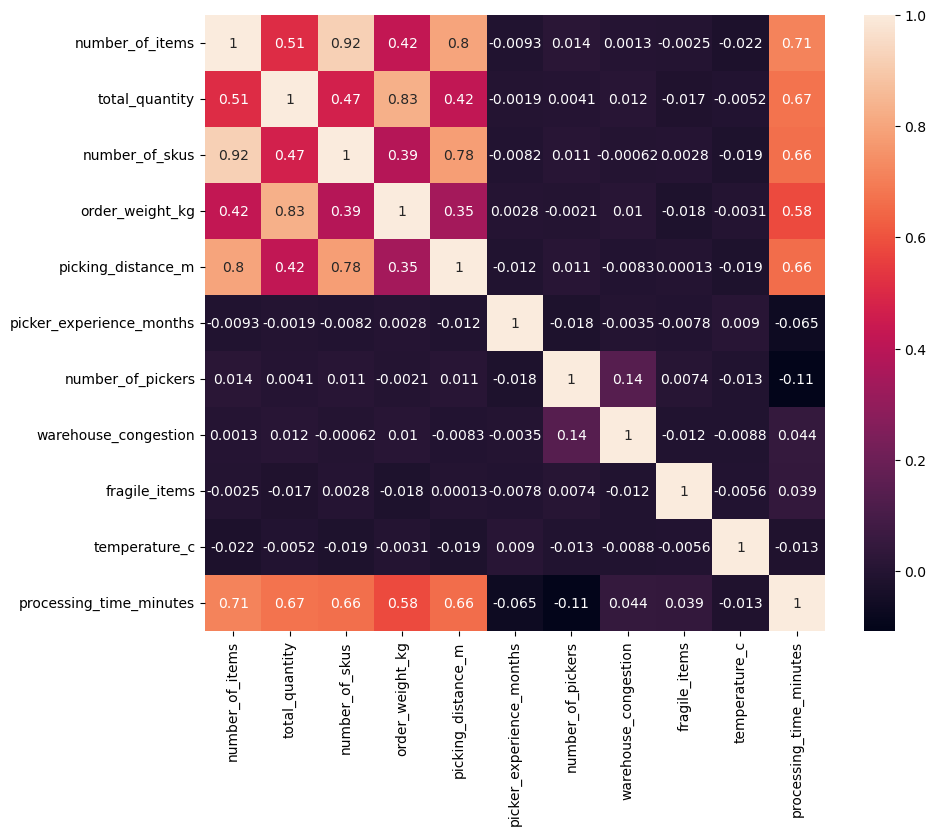

In [112]:
plt.figure(figsize=(10,8))

sns.heatmap(df[numerical_cols].corr(), annot= True)

### below features are correlated to target variable in positive direction
processing_time_minutes     
number_of_items            
total_quantity              
number_of_skus              
picking_distance_m         
order_weight_kg   

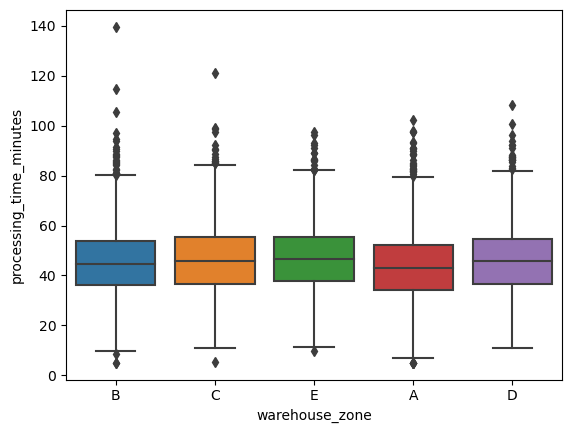

In [116]:
sns.boxplot(x='warehouse_zone', y='processing_time_minutes', data=df)
plt.show()

In [119]:
df.head()

,order_id,order_date,shift,warehouse_zone,priority,equipment_type,day_of_week,number_of_items,total_quantity,number_of_skus,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,temperature_c,processing_time_minutes
0,104680,2026-07-14 23:00:00,Afternoon,B,Standard,Trolley,Tuesday,10,22,8,5.98,388.0,31.0,1,0.414,0,27.4,38.18
1,110474,2027-03-13 09:00:00,Morning,C,Standard,Manual,Saturday,11,33,7,18.97,507.2,31.0,1,0.260,0,25.5,60.78
2,110501,2027-03-14 12:00:00,Morning,B,Standard,Trolley,Sunday,9,28,8,5.91,403.5,8.0,1,0.254,0,26.7,36.50
3,108702,2026-12-29 13:00:00,Night,B,Standard,Manual,Tuesday,9,19,7,13.46,489.2,53.0,3,0.336,0,25.7,39.86
4,107174,2026-10-26 21:00:00,Afternoon,B,Standard,Manual,Monday,11,33,9,13.01,655.1,20.0,2,0.511,3,34.6,44.72
